In [1]:
#Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

sns.set_theme(style="whitegrid")

In [2]:
# Caminhos

gold = "E:/POS_GRADUACAO/FASE3_V2/tech_challenge_fase3/data/gold_alfabetizacao.csv"
pasta_imagens = "E:/POS_GRADUACAO/FASE3_V2/tech_challenge_fase3/images/"
pasta_reports = "E:/POS_GRADUACAO/FASE3_V2/tech_challenge_fase3/reports/"

In [3]:
df = pd.read_csv(gold)
print(df.shape)
df.dtypes

(3867999, 44)


ano                                       int64
id_municipio                              int64
id_aluno                                  int64
caderno                                   int64
serie                                     int64
rede                                      int64
presenca                                  int64
preenchimento_caderno                     int64
proficiencia                            float64
peso_aluno                              float64
alfabetizado                              int64
cadun_qtd_pessoas_cadastradas_i         float64
qtd_pes_pob                             float64
qtd_pes_baixa_renda                     float64
qtd_pes_acima_meio_sm                   float64
populacao                               float64
nome_municipio                           object
uf                                       object
regiao_geografica_intermediaria           int64
nome_regiao_geografica_intermediaria     object
regiao_geografica_imediata              

In [4]:
print("Registros elegíveis:", (df["elegivel_modelagem"] == 1).sum())
print("Registros não elegíveis:", (df["elegivel_modelagem"] == 0).sum())

Registros elegíveis: 3354661
Registros não elegíveis: 513338


alfabetizado
0    1370115
1    1984546
Name: count, dtype: int64
alfabetizado
0    40.84
1    59.16
Name: proportion, dtype: float64


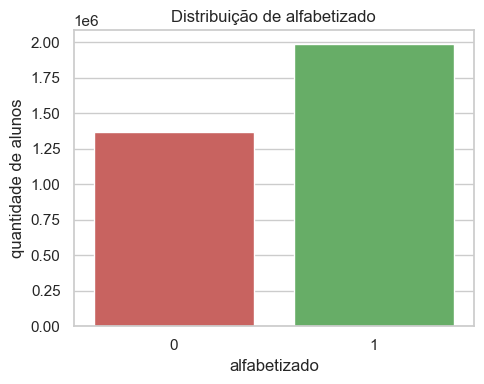

In [5]:
df_elegivel = df[df["elegivel_modelagem"] == 1].copy()

dist_alvo = df_elegivel["alfabetizado"].value_counts().sort_index()
dist_alvo_pct = df_elegivel["alfabetizado"].value_counts(normalize=True).sort_index() * 100

print(dist_alvo)
print(dist_alvo_pct.round(2))

plt.figure(figsize=(5, 4))
sns.barplot(x=dist_alvo.index.astype(str), y=dist_alvo.values, hue=dist_alvo.index.astype(str), palette=["#d9534f", "#5cb85c"], legend=False)
plt.title("Distribuição de alfabetizado")
plt.xlabel("alfabetizado")
plt.ylabel("quantidade de alunos")
plt.tight_layout()
plt.savefig(f"{pasta_imagens}/01_distribuicao_alvo.png", dpi=120)
plt.show()

Registros por ano:
ano
2023    1747439
2024    2120560
Name: count, dtype: int64

Registros por ano (subconjunto elegível):
ano
2023    1502809
2024    1851852
Name: count, dtype: int64

Taxa de alfabetização observada por ano:
ano
2023    58.39
2024    59.78
Name: alfabetizado, dtype: float64


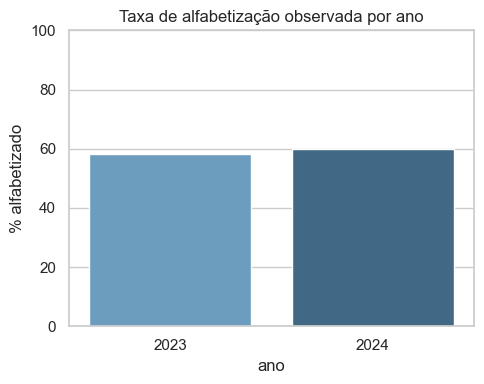

In [32]:
print("Registros por ano:")
print(df["ano"].value_counts().sort_index())

print("\nRegistros por ano (subconjunto elegível):")
print(df_elegivel["ano"].value_counts().sort_index())

print("\nTaxa de alfabetização observada por ano:")
taxa_por_ano = df_elegivel.groupby("ano")["alfabetizado"].mean() * 100
print(taxa_por_ano.round(2))

plt.figure(figsize=(5, 4))
sns.barplot(x=taxa_por_ano.index.astype(str), y=taxa_por_ano.values, hue=taxa_por_ano.index.astype(str), palette="Blues_d", legend=False)
plt.title("Taxa de alfabetização observada por ano")
plt.ylabel("% alfabetizado")
plt.xlabel("ano")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(f"{pasta_imagens}/02_taxa_por_ano.png", dpi=120)
plt.show()

## Planejo usar dados de 2023 para treinar o modelo e dados de 2024 para testar, os números acima mostra que não houve mudanças bruscas na taxa de alfabetização de um ano para o outro (2023 = 58.4% VS 2024 = 59.8%) o que me faz parecer seguro em seguir dessa forma 

In [34]:
print("Distribuição de rede:")
print(df_elegivel["rede"].value_counts().sort_index())

print("\nDistribuição de serie:")
print(df_elegivel["serie"].value_counts().sort_index())

print("\nQuantidade de valores distintos em caderno:", df_elegivel["caderno"].nunique())
print(df_elegivel["caderno"].value_counts().sort_index().head(10))

Distribuição de rede:
rede
2     372596
3    2982041
4         24
Name: count, dtype: int64

Distribuição de serie:
serie
2    3354661
Name: count, dtype: int64

Quantidade de valores distintos em caderno: 22
caderno
1     210902
2     163834
3     163871
4     163821
5     163489
6     163534
7     163252
8     156497
9     154450
10    155178
Name: count, dtype: int64


| coluna | valor | descrição |
|---|---|---|
| rede | 1 | Federal |
| rede | 2 | Estadual |
| rede | 3 | Municipal |
| rede | 4 | Privada |

---

| coluna | valor | descrição |
|---|---|---|
| serie | 2 | 2° ano do Ensino Fundamental |


#### A rede privada conta com apenas 24 alunos da rede privada, isso é irrelevante para o modelo já que é uma quantidade tão pequena.
#### Existe apenas 100% de dados do 2° ano do Ensino Fundamental, então já posso descartar essa coluna das features.

       mean    count
rede                
2     62.11   372596
3     58.79  2982041
4     66.67       24


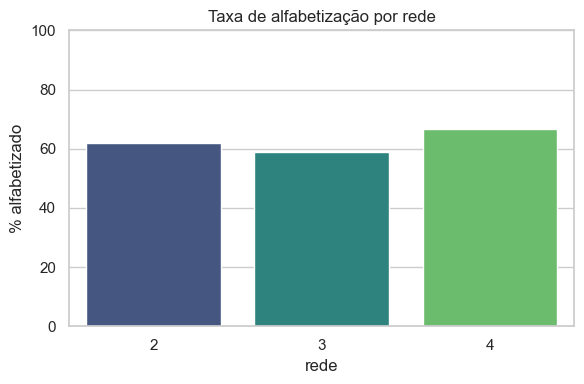

In [35]:
taxa_por_rede = df_elegivel.groupby("rede")["alfabetizado"].agg(["mean", "count"])
taxa_por_rede["mean"] = (taxa_por_rede["mean"] * 100).round(2)
print(taxa_por_rede)

plt.figure(figsize=(6, 4))
sns.barplot(x=taxa_por_rede.index.astype(str), y=taxa_por_rede["mean"], hue=taxa_por_rede.index.astype(str) ,palette="viridis", legend=False)
plt.title("Taxa de alfabetização por rede")
plt.ylabel("% alfabetizado")
plt.xlabel("rede")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(f"{pasta_imagens}/03_taxa_por_rede.png", dpi=120)
plt.show()

          mean   count
caderno               
1        58.84  210902
2        59.07  163834
3        59.24  163871
4        59.09  163821
5        59.46  163489
6        59.43  163534
7        58.95  163252
8        59.77  156497
9        59.12  154450
10       59.84  155178
11       58.73  155067
12       59.37  154728
13       58.94  155222
14       59.39  154899
15       58.69  156369
16       59.01  154773
17       59.36  153106
18       58.36  153459
19       59.07  151905
20       58.82  153544
21       59.86  152749
43       50.00      12


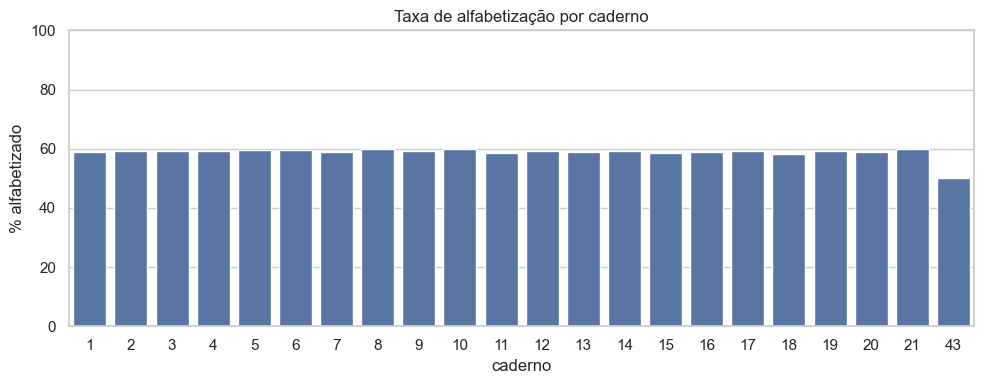

In [36]:
taxa_por_caderno = df_elegivel.groupby("caderno")["alfabetizado"].agg(["mean", "count"])
taxa_por_caderno["mean"] = (taxa_por_caderno["mean"] * 100).round(2)
print(taxa_por_caderno.sort_index())

plt.figure(figsize=(10, 4))
sns.barplot(x=taxa_por_caderno.index, y=taxa_por_caderno["mean"], color="#4C72B0")
plt.title("Taxa de alfabetização por caderno")
plt.ylabel("% alfabetizado")
plt.xlabel("caderno")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(f"{pasta_imagens}/04_taxa_por_caderno.png", dpi=120)
plt.show()

#### Caderno consta com 22 valores, todos muito parecidos e balanceados, aparentemente são cadernos gerados com tecnicas de aleatoriedade e equivalencia, exceto o cardeno 43 que por algum motivo foge da numeração padrão e consta apenas 12 registros, que são irrelevantes estatisticamente falando.

Estatísticas de população:
count    3,354,661
mean       826,430
std      2,201,562
min            854
25%         27,551
50%        101,302
75%        425,983
max     11,895,578
Name: populacao, dtype: float64


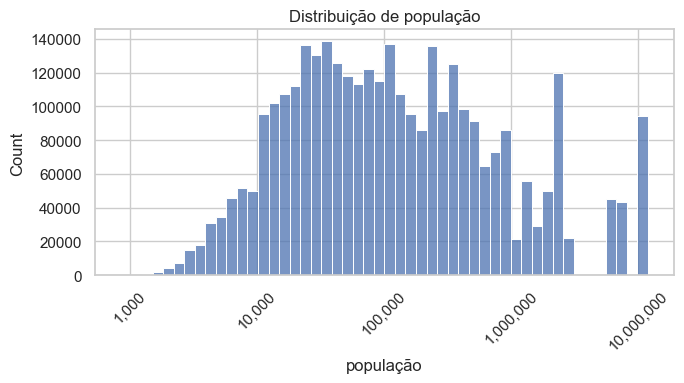


Taxa de alfabetização por UF:
                      mean   count
uf                                
Sergipe              34.85   36436
Bahia                36.70  220481
Rio Grande do Norte  38.93   47785
Amapá                44.47   22289
Alagoas              46.67   64364
Tocantins            46.93   33654
Pará                 49.00  167750
Amazonas             51.59   94638
Acre                 51.90   10234
Mato Grosso do Sul   52.14   74325
Paraíba              53.95   64718
Rio de Janeiro       54.61  255606
Rio Grande do Sul    55.69  188222
Piauí                56.61   64172
Mato Grosso          58.19   92779
Maranhão             58.51  129767
São Paulo            58.56  395444
Distrito Federal     59.43   22111
Pernambuco           60.09  157101
Santa Catarina       63.12  149691
Rondônia             64.14   40143
Minas Gerais         66.62  369007
Goiás                69.97  143667
Espírito Santo       70.19   87379
Paraná               72.22  239191
Ceará                85.

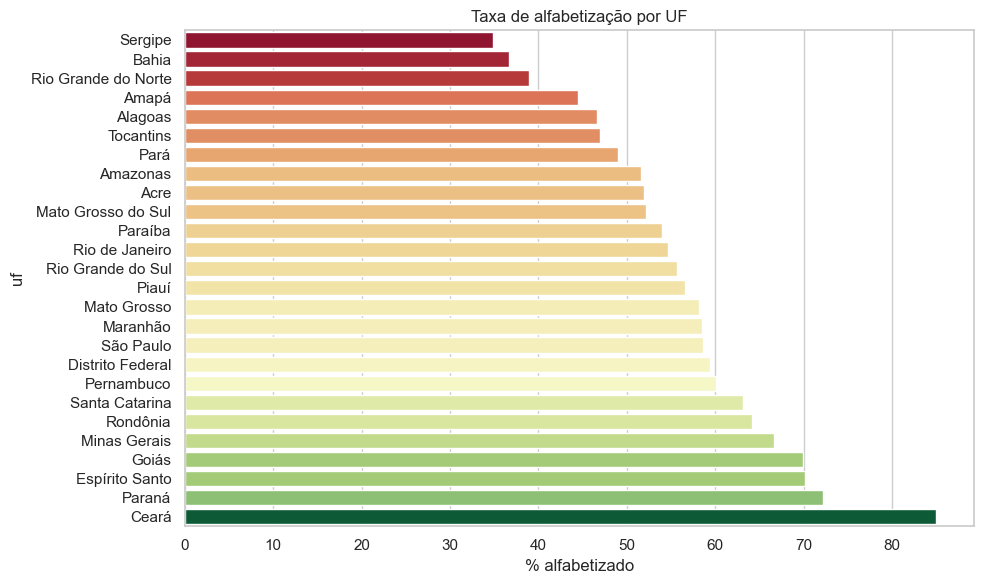

In [48]:
pd.options.display.float_format = "{:,.0f}".format

print("Estatísticas de população:")
print(df_elegivel["populacao"].describe())

plt.figure(figsize=(7, 4))
sns.histplot(df_elegivel["populacao"], bins=50, log_scale=True)
plt.title("Distribuição de população")
plt.xlabel("população")
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{pasta_imagens}/05_distribuicao_populacao.png", dpi=120)
plt.show()

pd.options.display.float_format = None 
print("\nTaxa de alfabetização por UF:")
taxa_por_uf = df_elegivel.groupby("uf")["alfabetizado"].agg(["mean", "count"]).sort_values("mean")
taxa_por_uf["mean"] = (taxa_por_uf["mean"] * 100).round(2)
print(taxa_por_uf)

plt.figure(figsize=(10, 6))
sns.barplot(x=taxa_por_uf["mean"], y=taxa_por_uf.index, hue=taxa_por_uf["mean"] ,palette="RdYlGn", orient="h", legend=False)
plt.title("Taxa de alfabetização por UF")
plt.xlabel("% alfabetizado")
plt.tight_layout()
plt.savefig(f"{pasta_imagens}/06_taxa_por_uf.png", dpi=120)
plt.show()

In [15]:
df_elegivel["pct_pes_cadastradas"] = df_elegivel["cadun_qtd_pessoas_cadastradas_i"] / df_elegivel["populacao"]
df_elegivel["pct_pes_pob"] = df_elegivel["qtd_pes_pob"] / df_elegivel["populacao"]
df_elegivel["pct_pes_baixa_renda"] = df_elegivel["qtd_pes_baixa_renda"] / df_elegivel["populacao"]
df_elegivel["pct_pes_acima_meio_sm"] = df_elegivel["qtd_pes_acima_meio_sm"] / df_elegivel["populacao"]

cols_pct = ["pct_pes_cadastradas", "pct_pes_pob", "pct_pes_baixa_renda", "pct_pes_acima_meio_sm"]

print("Estatísticas dos indicadores normalizados:")
print(df_elegivel[cols_pct].describe())

Estatísticas dos indicadores normalizados:
       pct_pes_cadastradas   pct_pes_pob  pct_pes_baixa_renda  \
count         3.354661e+06  3.354661e+06         3.354661e+06   
mean          4.979787e-01  2.653967e-01         1.103747e-01   
std           1.945760e-01  1.668870e-01         3.806083e-02   
min           3.433353e-02  9.517012e-04         6.749556e-03   
25%           3.329804e-01  1.326857e-01         8.074846e-02   
50%           4.755369e-01  2.244566e-01         1.067275e-01   
75%           6.465291e-01  3.709793e-01         1.351809e-01   
max           1.288882e+00  1.022054e+00         3.436426e-01   

       pct_pes_acima_meio_sm  
count           3.354661e+06  
mean            1.222073e-01  
std             4.360496e-02  
min             8.078477e-03  
25%             9.187997e-02  
50%             1.136727e-01  
75%             1.446518e-01  
max             5.587128e-01  


In [50]:
for col in cols_pct:
    acima_100 = (df_elegivel[col] > 1.0).sum()
    print(f"{col}: {acima_100:,} registros acima de 100%")

pct_pes_cadastradas: 9,796 registros acima de 100%
pct_pes_pob: 289 registros acima de 100%
pct_pes_baixa_renda: 0 registros acima de 100%
pct_pes_acima_meio_sm: 0 registros acima de 100%


In [54]:
cols_absolutas = ["cadun_qtd_pessoas_cadastradas_i", "qtd_pes_pob", "qtd_pes_baixa_renda", "qtd_pes_acima_meio_sm"]

print("Correlação entre indicadores ABSOLUTOS e população:")
print(df_elegivel[cols_absolutas + ["populacao"]].corr()["populacao"])

print("\nCorrelação entre indicadores NORMALIZADOS e população:")
print(df_elegivel[cols_pct + ["populacao"]].corr()["populacao"])

Correlação entre indicadores ABSOLUTOS e população:
cadun_qtd_pessoas_cadastradas_i    0.992937
qtd_pes_pob                        0.955521
qtd_pes_baixa_renda                0.991809
qtd_pes_acima_meio_sm              0.980582
populacao                          1.000000
Name: populacao, dtype: float64

Correlação entre indicadores NORMALIZADOS e população:
pct_pes_cadastradas     -0.264393
pct_pes_pob             -0.188410
pct_pes_baixa_renda     -0.297676
pct_pes_acima_meio_sm   -0.198867
populacao                1.000000
Name: populacao, dtype: float64


In [52]:
casos_estranhos = df_elegivel[df_elegivel["pct_pes_pob"] > 1.0]

print(f"Municípios distintos afetados (pct_pes_pob > 100%): {casos_estranhos['id_municipio'].nunique()}")
print(f"Anos afetados: {casos_estranhos['ano'].unique()}")

resumo = casos_estranhos.groupby(["id_municipio", "nome_municipio", "ano"]).agg(
    populacao=("populacao", "first"),
    qtd_pes_pob=("qtd_pes_pob", "first"),
    pct_pes_pob=("pct_pes_pob", "first")
).drop_duplicates().sort_values("pct_pes_pob", ascending=False)

print(resumo.head(15))

Municípios distintos afetados (pct_pes_pob > 100%): 2
Anos afetados: [2023 2024]
                                       populacao  qtd_pes_pob  pct_pes_pob
id_municipio nome_municipio      ano                                      
2111789      Serrano do Maranhão 2023    10202.0      10427.0     1.022054
1600253      Itaubal             2024     6043.0       6163.0     1.019858
                                 2023     5599.0       5693.0     1.016789


#### Existe um risco do modelo aprender que qtd_pes_pob é um valor alto e assumir alguma coisa, mas o valor pode ser alto por que o municipio tem uma população alta e isso não significa que o municipio é vuneravel, então normalizei através de percentual e pude ver os dados perderem a relação forte que tinham antes com o número absoluto.

#### Existem 2 múnicipios com o percentual acima de 100% e 1 municipio com valor nulo impossibilitando a identificação (que será provavelmente retirado depois)

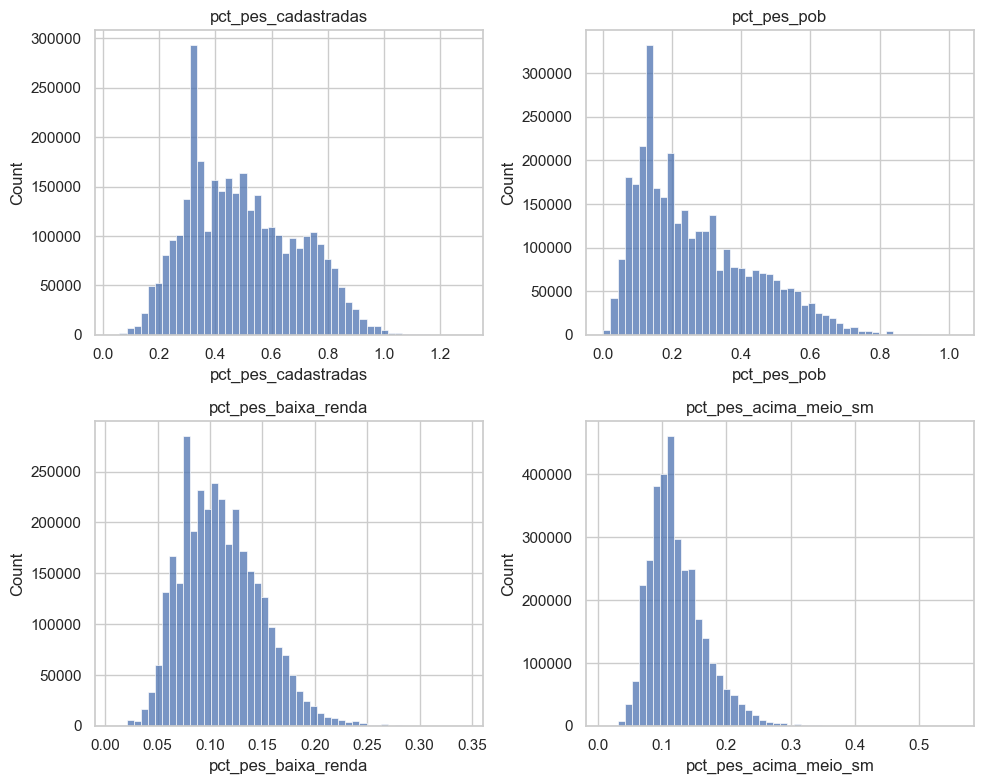

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, cols_pct):
    sns.histplot(df_elegivel[col], bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(f"{pasta_imagens}/07_distribuicao_cadunico_normalizado.png", dpi=120)
plt.show()

                   mean   count
quartil_pobreza                
Q1 (menos pobre)  65.10  909767
Q2                60.45  788438
Q3                56.13  818297
Q4 (mais pobre)   54.45  838159


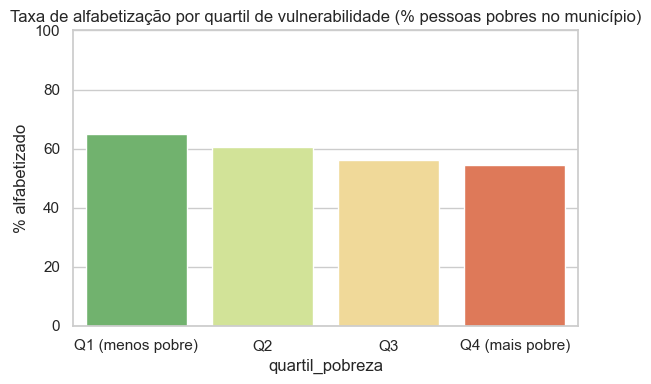

In [61]:
df_elegivel["quartil_pobreza"] = pd.qcut(df_elegivel["pct_pes_pob"], q=4, labels=["Q1 (menos pobre)", "Q2", "Q3", "Q4 (mais pobre)"])

taxa_por_quartil = df_elegivel.groupby("quartil_pobreza", observed=True)["alfabetizado"].agg(["mean", "count"])
taxa_por_quartil["mean"] = (taxa_por_quartil["mean"] * 100).round(2)
print(taxa_por_quartil)

plt.figure(figsize=(6, 4))
sns.barplot(x=taxa_por_quartil.index, y=taxa_por_quartil["mean"], hue=taxa_por_quartil.index ,palette="RdYlGn_r", legend=False)
plt.title("Taxa de alfabetização por quartil de vulnerabilidade (% pessoas pobres no município)")
plt.ylabel("% alfabetizado")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(f"{pasta_imagens}/08_taxa_por_quartil_pobreza.png", dpi=120)
plt.show()

#### Entre os alunos que estão no Q1 que mora nos municípios menos pobres, 65.10% são alfabetizados.

Municípios com dado de meta e taxa: 5,352
Já superaram a meta de 2025: 2,387
Ainda abaixo da meta de 2025: 2,965


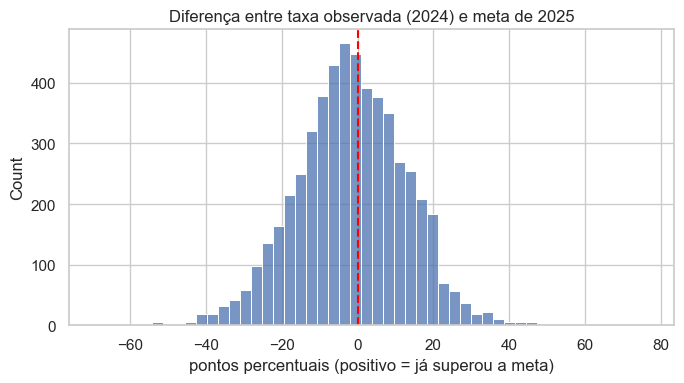

In [6]:
# Taxa de alfabetização observada por município
taxa_municipio_2024 = (
    df_elegivel[df_elegivel["ano"] == 2024]
    .groupby("id_municipio")["alfabetizado"]
    .mean() * 100
)

meta_2025_municipio = (
    df_elegivel[df_elegivel["ano"] == 2024]
    .groupby("id_municipio")["meta_municipio_2025"]
    .first()
)

comparacao = pd.DataFrame({
    "taxa_observada_2024": taxa_municipio_2024,
    "meta_2025": meta_2025_municipio
}).dropna()

comparacao["diferenca"] = comparacao["taxa_observada_2024"] - comparacao["meta_2025"]

print(f"Municípios com dado de meta e taxa: {len(comparacao):,}")
print(f"Já superaram a meta de 2025: {(comparacao['diferenca'] >= 0).sum():,}")
print(f"Ainda abaixo da meta de 2025: {(comparacao['diferenca'] < 0).sum():,}")

plt.figure(figsize=(7, 4))
sns.histplot(comparacao["diferenca"], bins=50)
plt.axvline(0, color="red", linestyle="--")
plt.title("Diferença entre taxa observada (2024) e meta de 2025")
plt.xlabel("pontos percentuais (positivo = já superou a meta)")
plt.tight_layout()
plt.savefig(f"{pasta_imagens}/09_distancia_meta_2025.png", dpi=120)
plt.show()

In [7]:
print("Nulos por coluna de meta municipal:")
print(df_elegivel[[c for c in df_elegivel.columns if c.startswith("meta_municipio")]].isnull().sum())

# Município sem qualquer meta municipal
sem_meta = df_elegivel[df_elegivel["meta_municipio_2025"].isnull()]

print(f"\nRegistros sem meta municipal: {len(sem_meta):,}")
print(f"Municípios distintos sem meta: {sem_meta['id_municipio'].nunique()}")

print("\nDistribuição por UF dos registros sem meta municipal:")
print(sem_meta["uf"].value_counts())

Nulos por coluna de meta municipal:
meta_municipio_2024    148135
meta_municipio_2025    107335
meta_municipio_2026    107335
meta_municipio_2027    107335
meta_municipio_2028    107335
meta_municipio_2029    107335
meta_municipio_2030    107335
dtype: int64

Registros sem meta municipal: 107,335
Municípios distintos sem meta: 195

Distribuição por UF dos registros sem meta municipal:
uf
Santa Catarina         41575
Distrito Federal       22111
Rio Grande do Sul      21157
Rio Grande do Norte     9658
Amazonas                3809
Minas Gerais            3332
Bahia                   3000
São Paulo               1093
Pará                     966
Mato Grosso              384
Pernambuco                84
Tocantins                 65
Paraná                    64
Paraíba                   37
Name: count, dtype: int64


In [12]:
print("Municípios distintos sem meta, por UF:")
print(sem_meta.groupby("uf")["id_municipio"].nunique().sort_values(ascending=False))

print(f"\n{sem_meta[sem_meta["uf"] == "Distrito Federal"]["id_municipio"].nunique()} município(s) distinto(s) no DF sem meta")

# Para SC e RS: são poucos municípios concentrando muitos alunos, ou muitos municípios pequenos?
top_sc_rs = (
    sem_meta[sem_meta["uf"].isin(["Santa Catarina", "Rio Grande do Sul"])]
    .groupby(["uf", "id_municipio", "nome_municipio"])
    .size()
    .sort_values(ascending=False)
)
print("\nTop municípios de SC/RS sem meta, por volume de registros:\n")
print(top_sc_rs.head(15))

Municípios distintos sem meta, por UF:
uf
Rio Grande do Sul      52
Santa Catarina         41
Minas Gerais           35
Bahia                  19
São Paulo              16
Rio Grande do Norte    16
Amazonas                7
Paraíba                 2
Pará                    2
Distrito Federal        1
Paraná                  1
Mato Grosso             1
Pernambuco              1
Tocantins               1
Name: id_municipio, dtype: int64

1 município(s) distinto(s) no DF sem meta

Top municípios de SC/RS sem meta, por volume de registros:

uf                 id_municipio  nome_municipio      
Rio Grande do Sul  4314902       Porto Alegre            15732
Santa Catarina     4205407       Florianópolis            5768
                   4208203       Itajaí                   5115
                   4216602       São José                 4136
                   4211900       Palhoça                  3966
                   4211306       Navegantes               2108
                   420830

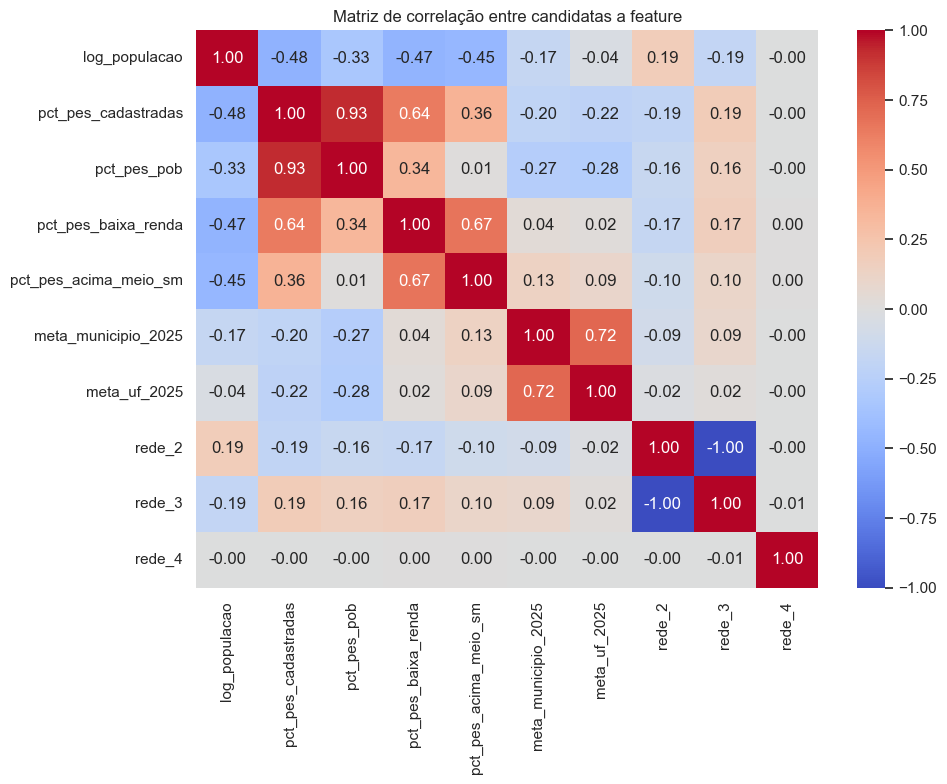

In [20]:
# log da população
df_elegivel["log_populacao"] = np.log1p(df_elegivel["populacao"])

# one-hot de rede só para fins desta análise de correlação (não é a codificação final do pipeline)
rede_dummies = pd.get_dummies(df_elegivel["rede"], prefix="rede")

cols_correlacao = [
    "log_populacao",
    "pct_pes_cadastradas", "pct_pes_pob", "pct_pes_baixa_renda", "pct_pes_acima_meio_sm",
    "meta_municipio_2025", "meta_uf_2025"
]

df_corr = pd.concat([df_elegivel[cols_correlacao], rede_dummies], axis=1)

matriz_corr = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlação entre candidatas a feature")
plt.tight_layout()
plt.savefig(f"{pasta_imagens}/10_matriz_correlacao.png", dpi=120)
plt.show()

In [21]:
pares_altos = (
    matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pares_altos.columns = ["variavel_1", "variavel_2", "correlacao"]
pares_altos = pares_altos[pares_altos["correlacao"].abs() > 0.7].sort_values("correlacao", key=abs, ascending=False)

print("Pares com |correlação| > 0.7:")
print(pares_altos)

Pares com |correlação| > 0.7:
             variavel_1    variavel_2  correlacao
42               rede_2        rede_3   -0.999964
9   pct_pes_cadastradas   pct_pes_pob    0.925974
35  meta_municipio_2025  meta_uf_2025    0.718892


Percentis de peso_aluno:
count    3.354661e+06
mean     1.148490e+00
std      3.585160e-01
min      9.523810e-02
1%       8.106233e-01
5%       9.454545e-01
25%      1.000709e+00
50%      1.091625e+00
75%      1.208405e+00
95%      1.508040e+00
99%      1.978734e+00
max      1.425454e+02
Name: peso_aluno, dtype: float64

Limites IQR: [0.69, 1.52]
Registros fora dos limites: 174,136 (5.19%)


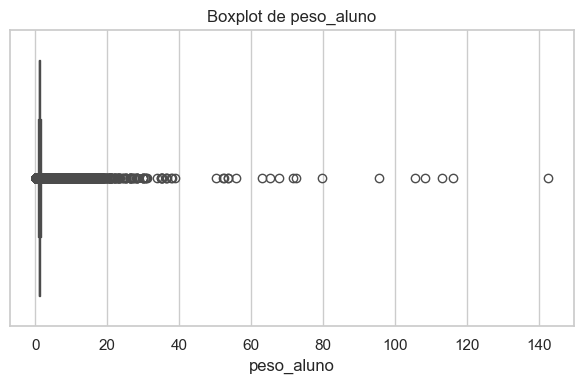

In [22]:
print("Percentis de peso_aluno:")
print(df_elegivel["peso_aluno"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

Q1 = df_elegivel["peso_aluno"].quantile(0.25)
Q3 = df_elegivel["peso_aluno"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_peso = df_elegivel[(df_elegivel["peso_aluno"] < limite_inferior) | (df_elegivel["peso_aluno"] > limite_superior)]
print(f"\nLimites IQR: [{limite_inferior:.2f}, {limite_superior:.2f}]")
print(f"Registros fora dos limites: {len(outliers_peso):,} ({len(outliers_peso)/len(df_elegivel)*100:.2f}%)")

plt.figure(figsize=(6, 4))
sns.boxplot(x=df_elegivel["peso_aluno"])
plt.title("Boxplot de peso_aluno")
plt.tight_layout()
plt.savefig(f"{pasta_imagens}/11_boxplot_peso_aluno.png", dpi=120)
plt.show()

In [23]:
for col in cols_pct:
    Q1 = df_elegivel[col].quantile(0.25)
    Q3 = df_elegivel[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_outliers = ((df_elegivel[col] < lim_inf) | (df_elegivel[col] > lim_sup)).sum()
    print(f"{col}: limites [{lim_inf:.3f}, {lim_sup:.3f}] -> {n_outliers:,} outliers ({n_outliers/len(df_elegivel)*100:.2f}%)")

pct_pes_cadastradas: limites [-0.137, 1.117] -> 1,770 outliers (0.05%)
pct_pes_pob: limites [-0.225, 0.728] -> 26,884 outliers (0.80%)
pct_pes_baixa_renda: limites [-0.001, 0.217] -> 29,332 outliers (0.87%)
pct_pes_acima_meio_sm: limites [0.013, 0.224] -> 85,658 outliers (2.55%)


In [18]:
print(df_elegivel["peso_aluno"].describe())
print("\nCorrelação de peso_aluno com alfabetizado:", df_elegivel["peso_aluno"].corr(df_elegivel["alfabetizado"]))
print("Correlação de peso_aluno com log_populacao:", df_elegivel["peso_aluno"].corr(df_elegivel["log_populacao"]))

count    3.354661e+06
mean     1.148490e+00
std      3.585160e-01
min      9.523810e-02
25%      1.000709e+00
50%      1.091625e+00
75%      1.208405e+00
max      1.425454e+02
Name: peso_aluno, dtype: float64

Correlação de peso_aluno com alfabetizado: -0.04852043713203686
Correlação de peso_aluno com log_populacao: 0.07549050777547416


## Conclusão EDA

A análise exploratória foi feita sobre 3.354.661 registros elegíveis
(alunos com proficiência aferida), de um total de 3.867.999 no
Indicador Criança Alfabetizada 2023-2024.

**Principais achados:**

- O alvo é razoavelmente balanceado (59,16% alfabetizados / 40,84% não), sem necessidade de balanceamento de classes.
- A taxa de alfabetização é estável entre 2023 e 2024 (58,39% → 59,78%), o que sustenta o treino em 2023 e teste em 2024 como estratégia de validação.
- **Território é o fator com maior variação isolada observada**: A taxa por UF varia de 34,85% (Sergipe) a 85,01% (Ceará) uma diferença de mais de 50 pontos percentuais.
- **Vulnerabilidade socioeconômica municipal (CadÚnico) tem relação clara com o alvo**: municípios no quartil mais pobre têm taxa de alfabetização ~10,6 pontos percentuais menor que os do quartil menos pobre.
- As colunas absolutas do CadÚnico são quase redundantes com população (correlação ~0,96-0,99) as versões normalizadas por população carregam sinal próprio de vulnerabilidade.
- ~5,3% dos registros não têm meta municipal definida, concentrados principalmente em municípios de Santa Catarina e Rio Grande do Sul.
- `serie` e `caderno` não carregam sinal preditivo relevante (serie é constante, a taxa é uniforme entre as 21 versões válidas de caderno).
- `peso_aluno` é um peso de ponderação, não uma característica do aluno e não deve ser usado como feature de classificação.

**Decisões para a etapa de modelagem**:

1. Remover registros com `rede = 4` (24 registros, resíduo).
2. Remover registros com `caderno = 43` (12 registros, resíduo).
3. Não usar `serie` e `caderno` como features.
4. Usar apenas os indicadores normalizados do CadÚnico (`pct_pes_pob`, `pct_pes_baixa_renda`, `pct_pes_acima_meio_sm`), descartando `pct_pes_cadastradas` (redundante) e os valores absolutos.
5. Aplicar clip em 1.0 nos indicadores percentuais (afeta 2 municípios com leve defasagem entre estimativa populacional do IBGE e contagem do CadÚnico).
6. Não usar `peso_aluno`, `presenca`, `preenchimento_caderno` e `proficiencia` das features (peso amostral, constantes pós-filtro, ou determinante direto do alvo).
7. Usar `log_populacao` no lugar de `populacao` crua.
8. Incluir `rede` e `uf` como features categóricas, com one-hot encoding e `drop_first=True` para evitar informação redundante principalmente em rede que terá apenas 2 informações únicas.
9. Não usar `id_municipio` como feature (risco de overfitting por causa da granularidade) mantido apenas como chave para agregações pós-modelo (ex: risco por município).